In [23]:
from pathlib import Path
import sys
import time
import statistics
import platform

import torch
import pandas as pd
import matplotlib.pyplot as plt


cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)
print("PyTorch:", torch.__version__)
print("System:", platform.platform())

Project root: /Users/salmannasyrov/PycharmProjects/ai360-recsys-2026
PyTorch: 2.14.1
System: macOS-15.5-arm64-arm-64bit-Mach-O


In [24]:
from src.data import load_prepared
from src.polynomial import FactorizedPolynomialRegression

In [25]:
data = load_prepared(
    "data/processed/movielens1m"
)

print("Train rows:", len(data.train))
print("Validation rows:", len(data.validation))
print("Test rows:", len(data.test))

print()
print("Users:", data.n_users)
print("Items:", data.n_items)

n_features = (
    data.n_users
    + data.n_items
)

print("Total one-hot features:", n_features)

Train rows: 700146
Validation rows: 150002
Test rows: 149990

Users: 6040
Items: 3652
Total one-hot features: 9692


In [8]:
data.train.head()

,row_id,user_id,item_id,rating,timestamp,user_idx,item_idx,known_user,known_item
0,0,1,1193,5,978300760,0,1079,True,True
1,1,1,661,3,978302109,0,632,True,True
2,2,1,914,3,978301968,0,831,True,True
3,3,1,3408,4,978300275,0,3129,True,True
4,5,1,1197,3,978302268,0,1082,True,True


In [26]:
def make_one_hot_features(
    frame,
    n_users,
    n_items,
):
    n_samples = len(frame)

    n_features = (
        n_users
        + n_items
    )

    x = torch.zeros(
        n_samples,
        n_features,
        dtype=torch.float32,
    )

    rows = torch.arange(
        n_samples
    )

    user_idx = torch.tensor(
        frame["user_idx"].to_numpy(),
        dtype=torch.long,
    )

    item_idx = torch.tensor(
        frame["item_idx"].to_numpy(),
        dtype=torch.long,
    )

    # User features:
    # [0, n_users)
    x[
        rows,
        user_idx,
    ] = 1.0

    # Item features:
    # [n_users, n_users + n_items)
    x[
        rows,
        n_users + item_idx,
    ] = 1.0

    ratings = torch.tensor(
        frame["rating"].to_numpy(),
        dtype=torch.float32,
    )

    return x, ratings

In [27]:
x_train, y_train = make_one_hot_features(
    data.train,
    data.n_users,
    data.n_items,
)

print("X shape:", x_train.shape)
print("y shape:", y_train.shape)

print()
print("First rating:", y_train[0].item())

print(
    "Active features in first sample:",
    torch.nonzero(
        x_train[0]
    ).flatten().tolist(),
)

X shape: torch.Size([700146, 9692])
y shape: torch.Size([700146])

First rating: 5.0
Active features in first sample: [0, 7119]


In [28]:
active_features = (
    x_train.sum(dim=1)
)

print(
    "All samples have exactly two active features:",
    torch.all(
        active_features == 2
    ).item(),
)

print(
    "First 10 feature counts:",
    active_features[:10],
)

All samples have exactly two active features: True
First 10 feature counts: tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])


In [29]:
torch.manual_seed(42)

n_factors = 16

model = FactorizedPolynomialRegression(
    n_features=n_features,
    n_factors=n_factors,
)

print(model)

FactorizedPolynomialRegression()


In [30]:
batch_size = 8

x_batch = x_train[
    :batch_size
]

user_idx = torch.tensor(
    data.train.iloc[
        :batch_size
    ]["user_idx"].to_numpy(),
    dtype=torch.long,
)

item_idx = torch.tensor(
    data.train.iloc[
        :batch_size
    ]["item_idx"].to_numpy(),
    dtype=torch.long,
)

rating_batch = y_train[
    :batch_size
]

print("Batch shape:", x_batch.shape)

print("Users:")
print(user_idx)

print()

print("Items:")
print(item_idx)

print()

print("Ratings:")
print(rating_batch)

Batch shape: torch.Size([8, 9692])
Users:
tensor([0, 0, 0, 0, 0, 0, 0, 0])

Items:
tensor([1079,  632,  831, 3129, 1082, 1170, 2560,  577])

Ratings:
tensor([5., 3., 3., 4., 3., 5., 5., 4.])


In [31]:
with torch.no_grad():
    direct = model.interaction_direct(
        x_batch
    )

print(direct)

tensor([ 2.0659e-04, -6.1624e-04, -5.6902e-04,  4.7004e-04,  8.3259e-04,
        -9.9593e-05,  9.1023e-04,  7.5488e-04])


In [32]:
with torch.no_grad():
    fast = model.interaction_fast(
        x_batch
    )

print(fast)

tensor([ 2.0659e-04, -6.1624e-04, -5.6902e-04,  4.7004e-04,  8.3259e-04,
        -9.9593e-05,  9.1023e-04,  7.5488e-04])


In [33]:
with torch.no_grad():
    sparse_direct = (
        model.factors[
            user_idx
        ]
        *
        model.factors[
            data.n_users
            + item_idx
        ]
    ).sum(dim=1)

print(sparse_direct)

tensor([ 2.0659e-04, -6.1624e-04, -5.6902e-04,  4.7004e-04,  8.3259e-04,
        -9.9593e-05,  9.1023e-04,  7.5488e-04])


In [34]:
direct_fast_difference = (
    direct - fast
).abs()

direct_sparse_difference = (
    direct - sparse_direct
).abs()

print(
    "Max direct-fast difference:",
    direct_fast_difference.max().item(),
)

print(
    "Max direct-sparse difference:",
    direct_sparse_difference.max().item(),
)

print()

print(
    "Direct ≈ Fast:",
    torch.allclose(
        direct,
        fast,
        rtol=1e-5,
        atol=1e-5,
    ),
)

print(
    "Direct ≈ Sparse:",
    torch.allclose(
        direct,
        sparse_direct,
        rtol=1e-5,
        atol=1e-5,
    ),
)

Max direct-fast difference: 1.1641532182693481e-10
Max direct-sparse difference: 0.0

Direct ≈ Fast: True
Direct ≈ Sparse: True


In [35]:
def measure_time(
    function,
    repeats=20,
    warmup=3,
):
    measurements = []

    with torch.no_grad():
        for _ in range(warmup):
            function()

        for _ in range(repeats):
            start = time.perf_counter()

            function()

            end = time.perf_counter()

            measurements.append(
                end - start
            )

    return statistics.median(
        measurements
    )

In [36]:
direct_time = measure_time(
    lambda: model.interaction_direct(
        x_batch
    )
)

fast_time = measure_time(
    lambda: model.interaction_fast(
        x_batch
    )
)

sparse_time = measure_time(
    lambda: (
        model.factors[
            user_idx
        ]
        *
        model.factors[
            data.n_users
            + item_idx
        ]
    ).sum(dim=1)
)

print(
    f"Generic direct: "
    f"{direct_time * 1000:.4f} ms"
)

print(
    f"Fast FM:        "
    f"{fast_time * 1000:.4f} ms"
)

print(
    f"Sparse direct:  "
    f"{sparse_time * 1000:.4f} ms"
)

Generic direct: 3303.7209 ms
Fast FM:        0.1506 ms
Sparse direct:  0.0054 ms


In [37]:
fast_speedup = (
    direct_time
    / fast_time
)

sparse_speedup = (
    direct_time
    / sparse_time
)

print(
    f"Fast FM speedup over generic direct: "
    f"{fast_speedup:.2f}x"
)

print(
    f"Sparse MovieLens speedup over generic direct: "
    f"{sparse_speedup:.2f}x"
)

Fast FM speedup over generic direct: 21933.42x
Sparse MovieLens speedup over generic direct: 609936.55x


In [38]:
runtime_df = pd.DataFrame({
    "method": [
        "Generic direct",
        "Fast FM",
        "Sparse user-item",
    ],
    "runtime_ms": [
        direct_time * 1000,
        fast_time * 1000,
        sparse_time * 1000,
    ],
})

runtime_df

,method,runtime_ms
0,Generic direct,3303.720938
1,Fast FM,0.150625
2,Sparse user-item,0.005416


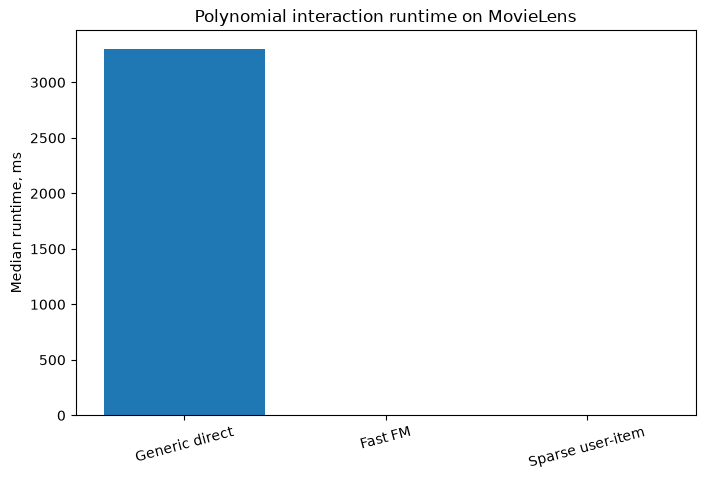

In [39]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    runtime_df["method"],
    runtime_df["runtime_ms"],
)

plt.ylabel(
    "Median runtime, ms"
)

plt.title(
    "Polynomial interaction runtime on MovieLens"
)

plt.xticks(
    rotation=15
)

plt.show()

In [40]:
n_users = data.n_users
n_items = data.n_items

n_features = (
    n_users
    + n_items
)

all_polynomial_pairs = (
    n_features
    * (n_features - 1)
    // 2
)

possible_user_item_pairs = (
    n_users
    * n_items
)

factorized_parameters = (
    n_features
    * n_factors
)

print(
    "All generic polynomial pairs:",
    all_polynomial_pairs,
)

print(
    "Possible user-item pairs:",
    possible_user_item_pairs,
)

print(
    "Factorized interaction parameters:",
    factorized_parameters,
)

All generic polynomial pairs: 46962586
Possible user-item pairs: 22058080
Factorized interaction parameters: 155072


In [41]:
generic_compression = (
    all_polynomial_pairs
    / factorized_parameters
)

user_item_compression = (
    possible_user_item_pairs
    / factorized_parameters
)

print(
    f"Generic polynomial / factorized: "
    f"{generic_compression:.2f}x"
)

print(
    f"User-item interactions / factorized: "
    f"{user_item_compression:.2f}x"
)

Generic polynomial / factorized: 302.84x
User-item interactions / factorized: 142.24x


In [42]:
parameter_df = pd.DataFrame({
    "representation": [
        "Generic second-order polynomial",
        "Explicit user-item interactions",
        "Factorized representation",
    ],
    "interaction_parameters": [
        all_polynomial_pairs,
        possible_user_item_pairs,
        factorized_parameters,
    ],
})

parameter_df

,representation,interaction_parameters
0,Generic second-order polynomial,46962586
1,Explicit user-item interactions,22058080
2,Factorized representation,155072


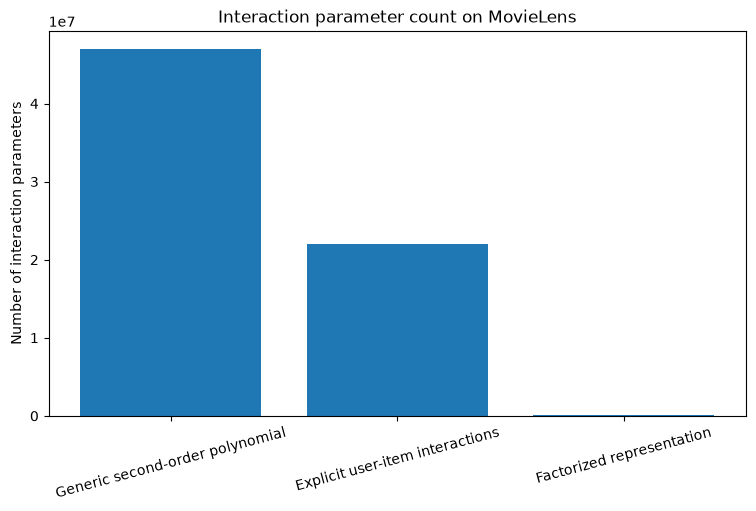

In [43]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    parameter_df["representation"],
    parameter_df[
        "interaction_parameters"
    ],
)

plt.ylabel(
    "Number of interaction parameters"
)

plt.title(
    "Interaction parameter count on MovieLens"
)

plt.xticks(
    rotation=15
)

plt.show()

In [44]:
import importlib
import src.polynomial

print("Loaded from:", src.polynomial.__file__)

importlib.reload(src.polynomial)

print(
    "UserItemPolynomialRegression2:",
    hasattr(
        src.polynomial,
        "UserItemPolynomialRegression2",
    ),
)

print(
    "UserItemFactorizedPolynomialRegression:",
    hasattr(
        src.polynomial,
        "UserItemFactorizedPolynomialRegression",
    ),
)

Loaded from: /Users/salmannasyrov/PycharmProjects/ai360-recsys-2026/src/polynomial.py
UserItemPolynomialRegression2: True
UserItemFactorizedPolynomialRegression: True


In [45]:
from src.models import (
    TrainingConfig,
    fit_model,
)

from src.polynomial import (
    UserItemPolynomialRegression2,
    UserItemFactorizedPolynomialRegression,
)

print("Training imports OK")

Training imports OK


In [46]:
def make_rating_tensors(frame):
    user_idx = torch.tensor(
        frame["user_idx"].to_numpy(),
        dtype=torch.long,
    )

    item_idx = torch.tensor(
        frame["item_idx"].to_numpy(),
        dtype=torch.long,
    )

    ratings = torch.tensor(
        frame["rating"].to_numpy(),
        dtype=torch.float32,
    )

    return user_idx, item_idx, ratings


train_users, train_items, train_ratings = make_rating_tensors(
    data.train
)

val_users, val_items, val_ratings = make_rating_tensors(
    data.validation
)

print("Train users:", train_users.shape)
print("Train items:", train_items.shape)
print("Train ratings:", train_ratings.shape)

print()

print("Validation users:", val_users.shape)
print("Validation items:", val_items.shape)
print("Validation ratings:", val_ratings.shape)

Train users: torch.Size([700146])
Train items: torch.Size([700146])
Train ratings: torch.Size([700146])

Validation users: torch.Size([150002])
Validation items: torch.Size([150002])
Validation ratings: torch.Size([150002])


In [47]:
from src.models import BiasModel, FactorizationMachine

poly_check = UserItemPolynomialRegression2(
    n_users=data.n_users,
    n_items=data.n_items,
)

factor_check = UserItemFactorizedPolynomialRegression(
    n_users=data.n_users,
    n_items=data.n_items,
    n_factors=4,
)

print(
    "Polynomial -> BiasModel:",
    isinstance(poly_check, BiasModel),
)

print(
    "Factorized -> BiasModel:",
    isinstance(factor_check, BiasModel),
)

print(
    "Factorized -> FactorizationMachine:",
    isinstance(factor_check, FactorizationMachine),
)

sample_users = train_users[:8]
sample_items = train_items[:8]

print(
    "Polynomial output:",
    poly_check(sample_users, sample_items).shape,
)

print(
    "Factorized output:",
    factor_check(sample_users, sample_items).shape,
)

Polynomial -> BiasModel: True
Factorized -> BiasModel: True
Factorized -> FactorizationMachine: True
Polynomial output: torch.Size([8])
Factorized output: torch.Size([8])


In [49]:
from src.models import TrainingConfig

training_config = TrainingConfig(
    epochs=200,
    batch_size=1024,
    learning_rate=0.01,
    optimizer="adam",
    reg_bias=0.01,
    reg_factors=0.05,
    patience=20,
    min_delta=0.0,
    seed=42,
)

training_config

TrainingConfig(epochs=200, batch_size=1024, learning_rate=0.01, optimizer='adam', reg_bias=0.01, reg_factors=0.05, patience=20, min_delta=0.0, seed=42)

In [62]:
import pandas as pd

k_values = [1, 2, 4, 8, 16]

factorized_runs = []

for k in k_values:
    print(f"\nTraining factorized polynomial with k={k}")

    model = UserItemFactorizedPolynomialRegression(
        n_users=data.n_users,
        n_items=data.n_items,
        n_factors=k,
    )

    result = fit_model(
        model,
        train_users,
        train_items,
        train_ratings,
        val_user_idx=val_users,
        val_item_idx=val_items,
        val_rating=val_ratings,
        config=training_config,
    )

    history = pd.DataFrame(result.history)

    best_row = history.loc[
        history["epoch"] == float(result.best_epoch)
    ].iloc[0]

    n_parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    factorized_runs.append({
        "k": k,
        "best_epoch": result.best_epoch,
        "train_rmse": best_row["train_rmse"],
        "validation_rmse": best_row["val_rmse"],
        "fit_seconds": result.fit_time_seconds,
        "parameters": n_parameters,
    })

factorized_k_df = pd.DataFrame(factorized_runs)

factorized_k_df


Training factorized polynomial with k=1

Training factorized polynomial with k=2

Training factorized polynomial with k=4

Training factorized polynomial with k=8

Training factorized polynomial with k=16


,k,best_epoch,train_rmse,validation_rmse,fit_seconds,parameters
0,1,2,1.094479,1.095217,5.906456,19385
1,2,2,1.094479,1.095217,6.092740,29077
2,4,2,1.094479,1.095217,6.346697,48461
3,8,2,1.094479,1.095217,9.177202,87229
4,16,2,1.094479,1.095217,12.674489,164765


In [63]:
from src.models import BiasModel

bias_model = BiasModel(
    n_users=data.n_users,
    n_items=data.n_items,
)

bias_result = fit_model(
    bias_model,
    train_users,
    train_items,
    train_ratings,
    val_user_idx=val_users,
    val_item_idx=val_items,
    val_rating=val_ratings,
    config=training_config,
)

bias_history = pd.DataFrame(
    bias_result.history
)

bias_best = bias_history.loc[
    bias_history["epoch"]
    == float(bias_result.best_epoch)
].iloc[0]

print("BiasModel")
print("best epoch:", bias_result.best_epoch)
print("train RMSE:", bias_best["train_rmse"])
print("validation RMSE:", bias_best["val_rmse"])

BiasModel
best epoch: 2
train RMSE: 1.094478964805603
validation RMSE: 1.0952173471450806


In [64]:
with torch.no_grad():
    print(
        "User factors mean abs:",
        model.user_factors.weight.abs().mean().item(),
    )

    print(
        "Item factors mean abs:",
        model.item_factors.weight.abs().mean().item(),
    )

    interaction = model.interaction_direct(
        val_users[:10000],
        val_items[:10000],
    )

    print(
        "Interaction mean abs:",
        interaction.abs().mean().item(),
    )

    print(
        "Interaction max abs:",
        interaction.abs().max().item(),
    )

User factors mean abs: 2.9452396120177582e-05
Item factors mean abs: 3.657307752291672e-05
Interaction mean abs: 1.9029068099030155e-08
Interaction max abs: 1.4337847460410558e-06


In [65]:
n_train = train_ratings.numel()

scaled_training_config = TrainingConfig(
    epochs=200,
    batch_size=1024,
    learning_rate=0.01,
    optimizer="adam",
    reg_bias=0.01 / n_train,
    reg_factors=0.05 / n_train,
    patience=20,
    min_delta=0.0,
    seed=42,
)

print("n_train:", n_train)
print("reg_bias:", scaled_training_config.reg_bias)
print("reg_factors:", scaled_training_config.reg_factors)

n_train: 700146
reg_bias: 1.4282735315205685e-08
reg_factors: 7.141367657602843e-08


In [66]:
test_model = UserItemFactorizedPolynomialRegression(
    n_users=data.n_users,
    n_items=data.n_items,
    n_factors=8,
)

test_result = fit_model(
    test_model,
    train_users,
    train_items,
    train_ratings,
    val_user_idx=val_users,
    val_item_idx=val_items,
    val_rating=val_ratings,
    config=scaled_training_config,
)

test_history = pd.DataFrame(
    test_result.history
)

best_row = test_history.loc[
    test_history["epoch"]
    == float(test_result.best_epoch)
].iloc[0]

print("Best epoch:", test_result.best_epoch)
print("Train RMSE:", best_row["train_rmse"])
print("Validation RMSE:", best_row["val_rmse"])
print("Fit seconds:", test_result.fit_time_seconds)

with torch.no_grad():
    interaction = test_model.interaction_direct(
        val_users[:10000],
        val_items[:10000],
    )

    print(
        "User factors mean abs:",
        test_model.user_factors.weight.abs().mean().item(),
    )
    print(
        "Item factors mean abs:",
        test_model.item_factors.weight.abs().mean().item(),
    )
    print(
        "Interaction mean abs:",
        interaction.abs().mean().item(),
    )
    print(
        "Interaction max abs:",
        interaction.abs().max().item(),
    )

Best epoch: 2
Train RMSE: 0.80716472864151
Validation RMSE: 0.8807409405708313
Fit seconds: 9.373589750000974
User factors mean abs: 0.29375317692756653
Item factors mean abs: 0.2876702547073364
Interaction mean abs: 0.2910114526748657
Interaction max abs: 2.9016518592834473


In [55]:
k_values = [2, 4, 8, 16]

factorized_runs = []

for k in k_values:
    print(f"\nTraining factorized polynomial with k={k}")

    model = UserItemFactorizedPolynomialRegression(
        n_users=data.n_users,
        n_items=data.n_items,
        n_factors=k,
    )

    result = fit_model(
        model,
        train_users,
        train_items,
        train_ratings,
        val_user_idx=val_users,
        val_item_idx=val_items,
        val_rating=val_ratings,
        config=scaled_training_config,
    )

    history = pd.DataFrame(
        result.history
    )

    best_row = history.loc[
        history["epoch"]
        == float(result.best_epoch)
    ].iloc[0]

    n_parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    factorized_runs.append({
        "k": k,
        "best_epoch": result.best_epoch,
        "train_rmse": best_row["train_rmse"],
        "validation_rmse": best_row["val_rmse"],
        "fit_seconds": result.fit_time_seconds,
        "parameters": n_parameters,
    })

factorized_k_df = pd.DataFrame(
    factorized_runs
)

factorized_k_df


Training factorized polynomial with k=2

Training factorized polynomial with k=4

Training factorized polynomial with k=8

Training factorized polynomial with k=16


,k,best_epoch,train_rmse,validation_rmse,fit_seconds,parameters
0,2,3,0.852778,0.884513,6.407093,29077
1,4,4,0.825903,0.882488,7.205636,48461
2,8,2,0.807165,0.880741,9.095650,87229
3,16,1,0.825499,0.888947,12.003535,164765


In [56]:
best_factorized_row = factorized_k_df.loc[
    factorized_k_df["validation_rmse"].idxmin()
]

best_factorized_row

k                      8.000000
best_epoch             2.000000
train_rmse             0.807165
validation_rmse        0.880741
fit_seconds            9.095650
parameters         87229.000000
Name: 2, dtype: float64

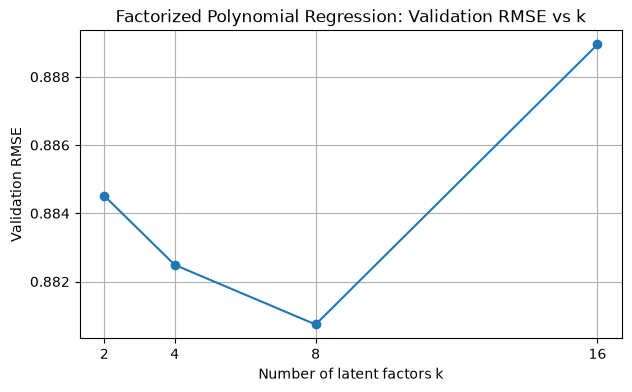

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    factorized_k_df["k"],
    factorized_k_df["validation_rmse"],
    marker="o",
)

plt.xlabel("Number of latent factors k")
plt.ylabel("Validation RMSE")
plt.title("Factorized Polynomial Regression: Validation RMSE vs k")

plt.xticks(factorized_k_df["k"])
plt.grid(True)

plt.show()

In [58]:
best_k = int(best_factorized_row["k"])

best_factorized_model = UserItemFactorizedPolynomialRegression(
    n_users=data.n_users,
    n_items=data.n_items,
    n_factors=best_k,
)

best_factorized_result = fit_model(
    best_factorized_model,
    train_users,
    train_items,
    train_ratings,
    val_user_idx=val_users,
    val_item_idx=val_items,
    val_rating=val_ratings,
    config=scaled_training_config,
)

best_factorized_history = pd.DataFrame(
    best_factorized_result.history
)

best_factorized_history.head()

,epoch,train_loss,train_mse,train_loss_with_regularization,train_rmse,val_rmse
0,1.0,0.719189,0.718739,0.719189,0.847785,0.888261
1,2.0,0.652272,0.651515,0.652272,0.807165,0.880741
2,3.0,0.627712,0.626747,0.627712,0.791673,0.883136
3,4.0,0.617126,0.616012,0.617126,0.784864,0.885495
4,5.0,0.611442,0.610212,0.611442,0.781160,0.888465


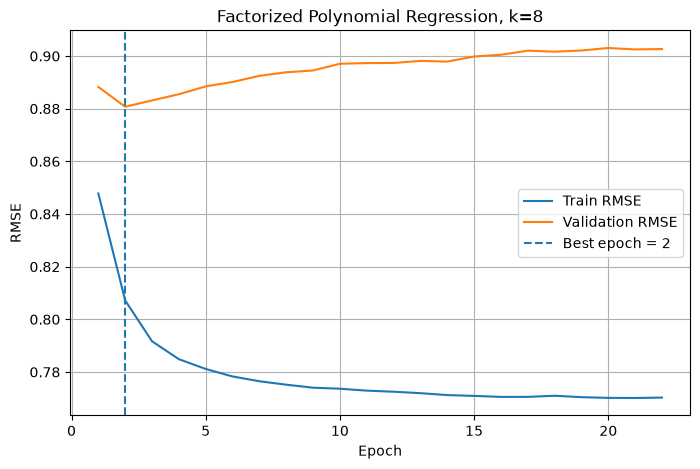

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_factorized_history["epoch"],
    best_factorized_history["train_rmse"],
    label="Train RMSE",
)

plt.plot(
    best_factorized_history["epoch"],
    best_factorized_history["val_rmse"],
    label="Validation RMSE",
)

plt.axvline(
    best_factorized_result.best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_factorized_result.best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title(
    f"Factorized Polynomial Regression, k={best_k}"
)

plt.legend()
plt.grid(True)

plt.show()

In [60]:
print("Best factorized polynomial model")
print("k:", best_k)
print("best epoch:", best_factorized_result.best_epoch)

best_row = best_factorized_history.loc[
    best_factorized_history["epoch"]
    == float(best_factorized_result.best_epoch)
].iloc[0]

print("train RMSE:", best_row["train_rmse"])
print("validation RMSE:", best_row["val_rmse"])
print("fit seconds:", best_factorized_result.fit_time_seconds)

n_parameters = sum(
    p.numel()
    for p in best_factorized_model.parameters()
    if p.requires_grad
)

print("parameters:", n_parameters)

Best factorized polynomial model
k: 8
best epoch: 2
train RMSE: 0.80716472864151
validation RMSE: 0.8807409405708313
fit seconds: 9.56287154200254
parameters: 87229
